<a href="https://colab.research.google.com/github/Julianajjss/tcc_dados_ips/blob/main/jsimao_ips_tcc_criacao_graficos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install geopandas pandasql
!pip install --quiet gdown


import gdown
import geopandas as gpd
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
from pandasql import sqldf
import unicodedata
import re

# Tratamentos na base

def remove_accents(input_str):
    """Removes accents from a string."""
    nfkd_form = unicodedata.normalize('NFKD', input_str)
    return ''.join([c for c in nfkd_form if not unicodedata.combining(c)])

def clean_ips_region_for_merge(region_name):
    """Specific cleaning for IPS region names to match mapa_ras."""

    region_name = str(region_name)
    cleaned_name = re.sub(r'\s+', '_', remove_accents(region_name).lower())


    cleaned_name = re.sub(r'^(x{0,3})(ix|iv|v?i{0,3})_r_a__', '', cleaned_name)

    cleaned_name = cleaned_name.replace('r_a__', '')


    cleaned_name = cleaned_name.replace('complexo_do_alemao', 'complexo_alemao')
    cleaned_name = cleaned_name.replace('complexo_da_mare', 'mare')
    cleaned_name = cleaned_name.replace('centro_da_cidade', 'centro')
    cleaned_name = cleaned_name.replace('ilha_do_governador', 'ilha_governador')
    cleaned_name = cleaned_name.replace('sao_cristovao', 'sao_cristovao')

    # Removendo _
    cleaned_name = re.sub(r'__+', '_', cleaned_name).strip('_')

    return cleaned_name


# Substitua o link abaixo pelo link que publiquei na web para ter o arquivo mais novo
url = 'https://docs.google.com/spreadsheets/d/e/2PACX-1vQWarx8Thc6rBTRtU3sPuJacd4vJ3A_31aCNThrowpYT04o6DNFThx21qmY_H-ugA/pub?gid=1460424820&single=true&output=csv'


ips = pd.read_csv(url)


for col in ips.columns:

    if col not in ['ano', 'regiao_administrativa']:
        if ips[col].dtype == 'object':
            cleaned_str_series = ips[col].astype(str).str.replace('.', '', regex=False).str.replace(',', '.', regex=False)
            ips[col] = pd.to_numeric(cleaned_str_series, errors='coerce')


ips['regiao_administrativa_cleaned'] = ips['regiao_administrativa'].apply(clean_ips_region_for_merge)


  Preparing metadata (setup.py) ... done
  Created wheel for pandasql: filename=pandasql-0.7.3-py3-none-any.whl size=26773 sha256=5b79fcf31ed2866ab73e54df7e8b288f4d284728df883d80c693e1c2e58e731a
  Stored in directory: /root/.cache/pip/wheels/15/a1/e7/6f92f295b5272ae5c02365e6b8fa19cb93f16a537090a1cf27
Successfully built pandasql


### **Criação do Mapa**

In [ ]:
# Pegando do Google Drive o arquivo geojson do Data Rio
gdrive_id = '1eS53B97GKxfcnsAGJGHnAkuZk1SHvbco'
local_filename = 'limite_ra_rio.geojson'

# Download do arquivo
gdown.download(f'https://drive.google.com/uc?id={gdrive_id}', local_filename, quiet=False)

# Lendo localmente o arquivo do Data Rio
mapa_ras = gpd.read_file(local_filename)

# Tratamento do arquivo
mapa_ras['nomera_cleaned'] = mapa_ras['nomera'].apply(clean_ips_region_for_merge)


mapa_ras = mapa_ras.dissolve(by='nomera_cleaned', aggfunc='first', as_index=False)


mapa_ras = mapa_ras[['nomera_cleaned', 'geometry']]


mapa_ras = mapa_ras[mapa_ras['geometry'].notna()]

print(f"Shape of mapa_ras after dissolve and cleaning: {mapa_ras.shape}")
print(f"Number of unique regions in mapa_ras: {mapa_ras['nomera_cleaned'].nunique()}")
print(f"Example rows from mapa_ras (head):\n{mapa_ras.head()}")

Downloading...
From: https://drive.google.com/uc?id=1eS53B97GKxfcnsAGJGHnAkuZk1SHvbco
To: /content/limite_ra_rio.geojson
100%|██████████| 3.18M/3.18M [00:00<00:00, 228MB/s]


Shape of mapa_ras after dissolve and cleaning: (33, 2)
Number of unique regions in mapa_ras: 33
Example rows from mapa_ras (head):
    nomera_cleaned                                           geometry
0         anchieta  POLYGON ((-43.41784 -22.82617, -43.41795 -22.8...
1            bangu  POLYGON ((-43.45027 -22.85649, -43.45034 -22.8...
2  barra_da_tijuca  MULTIPOLYGON (((-43.51099 -23.06143, -43.51087...
3         botafogo  MULTIPOLYGON (((-43.20107 -22.94803, -43.19918...
4     campo_grande  POLYGON ((-43.51515 -22.85229, -43.52039 -22.8...


### Junção da base ips para criação do mapa

In [ ]:
import geopandas as gpd

# Filtrando para o IPS do ano de 2022.
ips_2022 = ips[ips['ano'] == 2022].copy()

# Apagando duplicados - tratamento na base
ips_2022 = ips_2022.drop_duplicates(subset=['regiao_administrativa_cleaned'])

# Junção dos dataframes
mapa_final = mapa_ras.merge(ips_2022, left_on='nomera_cleaned', right_on='regiao_administrativa_cleaned', how='inner')

Criando o Mapa

In [ ]:
query = """
SELECT
    nomera_cleaned AS regiao_administrativa, -- Usar nomera_cleaned como a chave principal da região
    homicidios_por_acao_policial,
    NTILE(4) OVER (ORDER BY homicidios_por_acao_policial DESC) AS grupo,
    CASE
        WHEN NTILE(4) OVER (ORDER BY homicidios_por_acao_policial DESC) = 1 THEN '#FFFFE0' -- Amarelo Claro
        WHEN NTILE(4) OVER (ORDER BY homicidios_por_acao_policial DESC) = 2 THEN '#FFD700' -- Amarelo Escuro
        WHEN NTILE(4) OVER (ORDER BY homicidios_por_acao_policial DESC) = 3 THEN '#808080' -- Cinza
        WHEN NTILE(4) OVER (ORDER BY homicidios_por_acao_policial DESC) = 4 THEN '#D3D3D3' -- Cinza Claro
    END AS hex_cor
FROM mapa_final_for_sql -- Use the temporary DataFrame for SQL
"""


mapa_final_for_sql = mapa_final.copy()
if 'geometry' in mapa_final_for_sql.columns:
    mapa_final_for_sql = mapa_final_for_sql.drop(columns=['geometry'])

df_resultado = sqldf(query, locals())

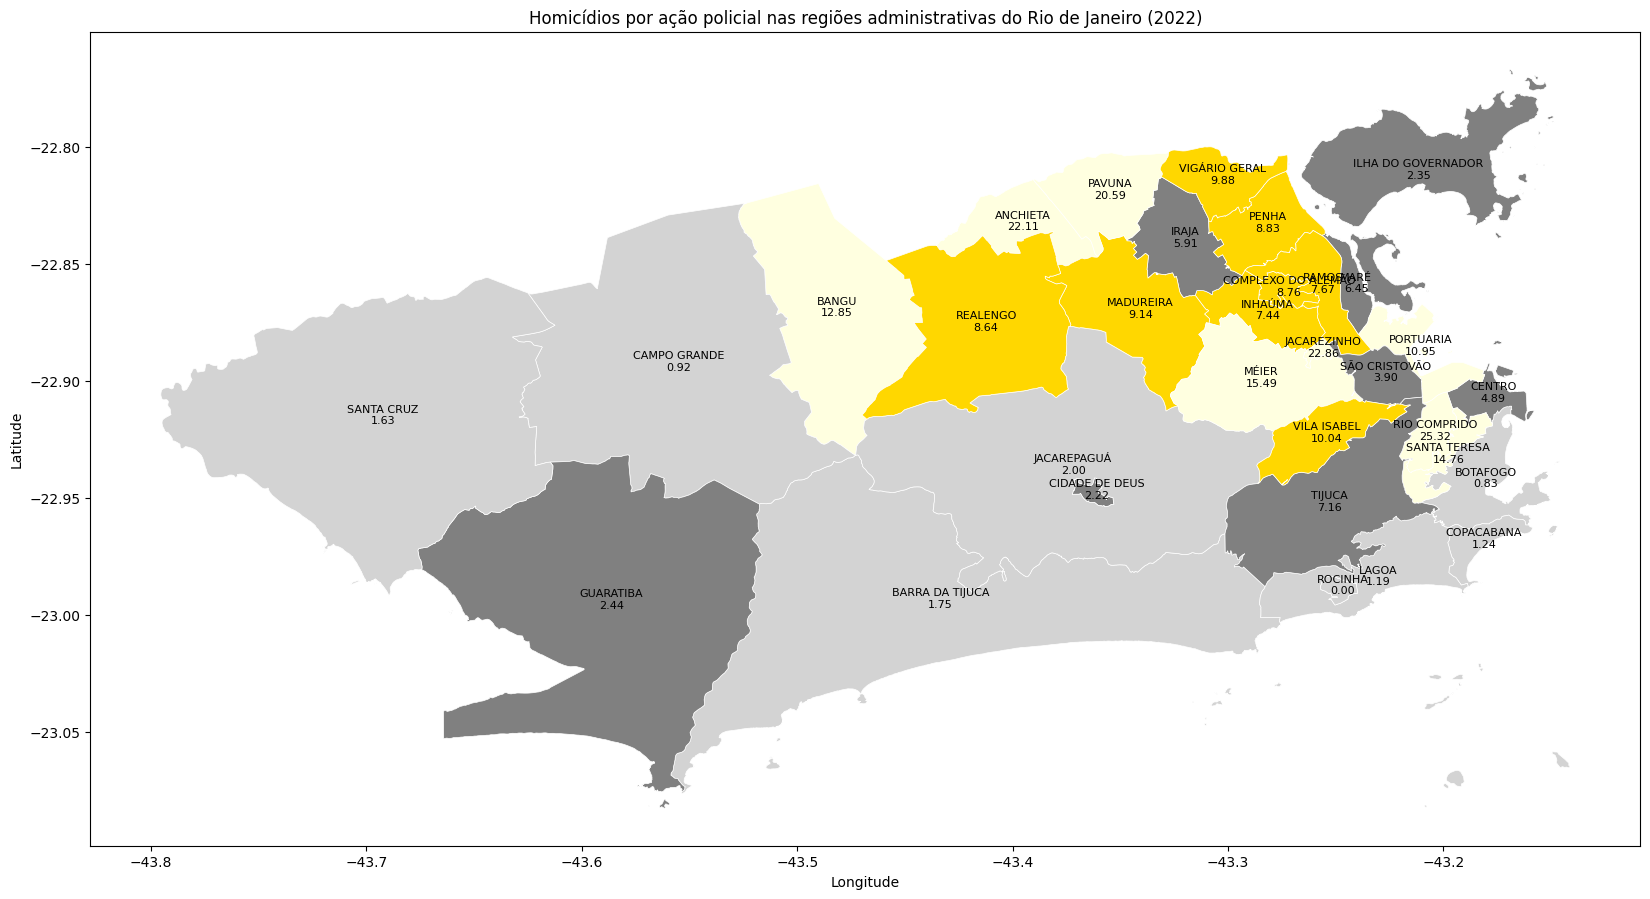

In [ ]:
mapa_final_com_cores = mapa_final.merge(df_resultado, left_on='nomera_cleaned', right_on='regiao_administrativa', how='left')


if not isinstance(mapa_final_com_cores, gpd.GeoDataFrame):
    mapa_final_com_cores = gpd.GeoDataFrame(mapa_final_com_cores, geometry='geometry')


mapa_final_com_cores['hex_cor'] = mapa_final_com_cores['hex_cor'].fillna('#CCCCCC') # Adicionado cor

fig, ax = plt.subplots(1, 1, figsize=(20, 20))
mapa_final_com_cores.plot(color=mapa_final_com_cores['hex_cor'], ax=ax, edgecolor='white', linewidth=0.5)


for idx, row in mapa_final_com_cores.iterrows():
    if row['geometry'] is not None and row['geometry'].centroid.x is not None and row['geometry'].centroid.y is not None:

        homicide_rate = row.get('homicidios_por_acao_policial_y')
        rate_text = f"{homicide_rate:.2f}" if pd.notna(homicide_rate) else "N/A"
        ax.annotate(
            text=f"{row['regiao_administrativa_x']}\n{rate_text}",
            xy=(row['geometry'].centroid.x, row['geometry'].centroid.y),
            xytext=(3, 3), textcoords="offset points",
            ha='center', va='center', fontsize=8, color='black'
        )

plt.title('Homicídios por ação policial nas regiões administrativas do Rio de Janeiro (2022)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()

**Destrinchando sobre a "engenharia de morte"**

 Enquanto em bairros como Lagoa e Botafogo a taxa de homicídios de jovens negros beira o zero, no território de Kathlen (Méier/Lins) e adjacências, o "alvo nas costas" é uma realidade estatística.

In [ ]:
query = """
SELECT
    regiao_administrativa_cleaned AS regiao,
    AVG(homicidios_de_jovens_negros) AS media_taxa
FROM ips
WHERE regiao_administrativa_cleaned IN (
    'meier', 'lagoa', 'copacabana', 'botafogo',
    'complexo_alemao', 'penha', 'jacarezinho', 'pavuna', 'anchieta'
)
  AND ano BETWEEN 2020 AND 2024
GROUP BY 1
ORDER BY 2 DESC;
"""

df_avg_selected_regions = sqldf(query, locals())
display(df_avg_selected_regions)

,regiao,media_taxa
0,pavuna,8.963333
1,anchieta,6.640000
2,penha,4.496667
3,meier,4.023333
4,complexo_alemao,3.256667
5,jacarezinho,2.686667
6,lagoa,0.423333
7,botafogo,0.296667
8,copacabana,0.236667


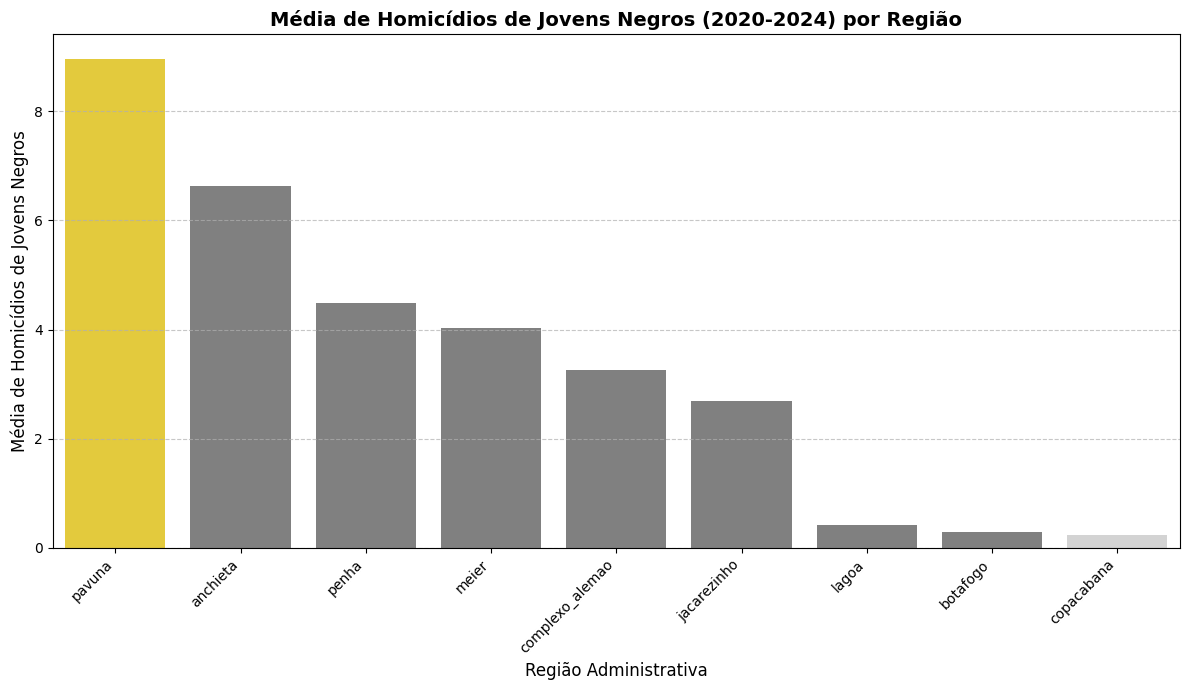

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a color list based on the values
colors = []
max_val = df_avg_selected_regions['media_taxa'].max()
min_val = df_avg_selected_regions['media_taxa'].min()

for val in df_avg_selected_regions['media_taxa']:
    if val == max_val:
        colors.append('#ffde21') # Adicionando cores
    elif val == min_val:
        colors.append('#D3D3D3') # Adicionando cores
    else:
        colors.append('#808080') # Adicionando cores

plt.figure(figsize=(12, 7))
sns.barplot(
    x='regiao',
    y='media_taxa',
    data=df_avg_selected_regions,
    hue='regiao',
    palette=colors,
    legend=False # Nao retornar legenda
)

plt.title('Média de Homicídios de Jovens Negros (2020-2024) por Região',
          fontsize=14, fontweight='bold')
plt.xlabel('Região Administrativa', fontsize=12)
plt.ylabel('Média de Homicídios de Jovens Negros', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

**Entendendo % de roubos de rua**

In [15]:
query = """
SELECT
    regiao_administrativa,
    ano,
    roubos_de_rua,
    homicidios_de_jovens_negros,
    vulnerabilidade_familiar,
    indice_de_acesso_a_cultura
FROM ips
WHERE regiao_administrativa_cleaned IN ("meier", "botafogo", "lagoa", "copacabana")
ORDER BY ano;
"""

df_indicators = sqldf(query, locals())
display(df_indicators)

,regiao_administrativa,ano,roubos_de_rua,homicidios_de_jovens_negros,vulnerabilidade_familiar,indice_de_acesso_a_cultura
0,BOTAFOGO,2016,8.16,2.50,0.01,68.39
1,COPACABANA,2016,3.34,1.24,0.01,27.93
2,LAGOA,2016,5.57,0.00,0.01,65.04
3,MÉIER,2016,10.35,6.50,0.01,64.13
4,BOTAFOGO,2018,9.66,1.67,0.00,58.81
5,COPACABANA,2018,6.73,3.10,0.01,32.22
6,LAGOA,2018,8.26,0.61,0.01,89.05
7,MÉIER,2018,13.63,7.11,0.01,32.66
8,BOTAFOGO,2020,11.40,0.42,0.00,58.81
9,COPACABANA,2020,9.95,0.00,0.01,32.22
